In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

full_dataset = pd.read_csv(
    "../data/processed/full_dataset.csv",
    parse_dates=["GAME_DATE"]
)

In [65]:
model_dataset = pd.read_csv(
    "../data/processed/model_dataset_v2.csv",
    parse_dates=["GAME_DATE"]
)

print(model_dataset.shape)
model_dataset.head()

(22000, 75)


,SEASON_ID,Player_ID,Game_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,...,FG3A_SEASON_AVG,FG3A_STD_LAST_5,FG3A_STD_LAST_10,FTA_LAST_GAME,FTA_LAST_5_AVG,FTA_LAST_10_AVG,FTA_SEASON_AVG,FTA_STD_LAST_5,FTA_STD_LAST_10,PLAYER_NAME
0,22025,1630173,22500197,2025-11-09,SAC vs. MIN,L,29,5,7,0.714,...,1.00,1.414214,1.414214,3.0,1.5,1.500000,1.500000,2.121320,2.121320,Precious Achiuwa
1,22025,1630173,22500212,2025-11-11,SAC vs. DEN,L,18,3,5,0.600,...,1.00,1.000000,1.000000,3.0,2.0,2.000000,2.000000,1.732051,1.732051,Precious Achiuwa
2,22025,1630173,22500223,2025-11-12,SAC vs. ATL,L,20,4,6,0.667,...,1.25,0.957427,0.957427,0.0,1.5,1.500000,1.500000,1.732051,1.732051,Precious Achiuwa
3,22025,1630173,22500044,2025-11-14,SAC @ MIN,L,20,2,4,0.500,...,1.00,1.000000,1.000000,4.0,2.0,2.000000,2.000000,1.870829,1.870829,Precious Achiuwa
4,22025,1630173,22500234,2025-11-16,SAC @ SAS,L,5,0,2,0.000,...,1.00,0.836660,0.894427,1.0,2.2,1.833333,1.833333,1.643168,1.722401,Precious Achiuwa


## Create target and features for testing

In [66]:
target = "PTS"

features = [
    "IS_HOME",
    "REST_DAYS",
    "GAMES_PLAYED",

    "PTS_LAST_GAME",
    "PTS_LAST_5_AVG",
    "PTS_LAST_10_AVG",
    "PTS_SEASON_AVG",
    "PTS_STD_LAST_5",
    "PTS_STD_LAST_10",

    "REB_LAST_GAME",
    "REB_LAST_5_AVG",
    "REB_LAST_10_AVG",
    "REB_SEASON_AVG",
    "REB_STD_LAST_5",
    "REB_STD_LAST_10",

    "AST_LAST_GAME",
    "AST_LAST_5_AVG",
    "AST_LAST_10_AVG",
    "AST_SEASON_AVG",
    "AST_STD_LAST_5",
    "AST_STD_LAST_10",

    "MIN_LAST_GAME",
    "MIN_LAST_5_AVG",
    "MIN_LAST_10_AVG",
    "MIN_SEASON_AVG",
    "MIN_STD_LAST_5",
    "MIN_STD_LAST_10",

    "FGA_LAST_GAME",
    "FGA_LAST_5_AVG",
    "FGA_LAST_10_AVG",
    "FGA_SEASON_AVG",
    "FGA_STD_LAST_5",
    "FGA_STD_LAST_10",

    "FG3A_LAST_GAME",
    "FG3A_LAST_5_AVG",
    "FG3A_LAST_10_AVG",
    "FG3A_SEASON_AVG",
    "FG3A_STD_LAST_5",
    "FG3A_STD_LAST_10",

    "FTA_LAST_GAME",
    "FTA_LAST_5_AVG",
    "FTA_LAST_10_AVG",
    "FTA_SEASON_AVG",
    "FTA_STD_LAST_5",
    "FTA_STD_LAST_10",
]

## Linear Regression Testing

In [67]:
model_dataset = model_dataset.sort_values("GAME_DATE").reset_index(drop=True)

split_index = int(len(model_dataset) * 0.8)

train = model_dataset.iloc[:split_index].copy()
test = model_dataset.iloc[split_index:].copy()

In [68]:
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [69]:
print("Training rows:", len(train))
print("Testing rows:", len(test))

print("\nTraining date range:")
print(train["GAME_DATE"].min(), "to", train["GAME_DATE"].max())

print("\nTesting date range:")
print(test["GAME_DATE"].min(), "to", test["GAME_DATE"].max())

print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

Training rows: 17600
Testing rows: 4400

Training date range:
2025-10-24 00:00:00 to 2026-03-11 00:00:00

Testing date range:
2026-03-11 00:00:00 to 2026-04-12 00:00:00

Feature shapes:
X_train: (17600, 45)
X_test: (4400, 45)


In [70]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print(f"MAE: {linear_mae:.2f}")
print(f"RMSE: {linear_rmse:.2f}")
print(f"R²: {linear_r2:.3f}")

Linear Regression Results
MAE: 4.81
RMSE: 6.27
R²: 0.458


In [72]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": linear_model.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients)

             Feature  Coefficient
30    FGA_SEASON_AVG     0.397962
6     PTS_SEASON_AVG     0.332902
17   AST_LAST_10_AVG     0.289986
35  FG3A_LAST_10_AVG     0.277536
14   REB_STD_LAST_10     0.215494
41   FTA_LAST_10_AVG     0.203479
12    REB_SEASON_AVG     0.197461
19    AST_STD_LAST_5     0.191498
10    REB_LAST_5_AVG     0.166035
37   FG3A_STD_LAST_5     0.127817
5    PTS_LAST_10_AVG     0.122308
42    FTA_SEASON_AVG     0.112060
22    MIN_LAST_5_AVG     0.111635
0            IS_HOME     0.100627
15     AST_LAST_GAME     0.089302
7     PTS_STD_LAST_5     0.079986
32   FGA_STD_LAST_10     0.075494
44   FTA_STD_LAST_10     0.073315
27     FGA_LAST_GAME     0.066542
38  FG3A_STD_LAST_10     0.065729
29   FGA_LAST_10_AVG     0.057768
21     MIN_LAST_GAME     0.056958
28    FGA_LAST_5_AVG     0.045452
43    FTA_STD_LAST_5     0.037162
39     FTA_LAST_GAME     0.025115
25    MIN_STD_LAST_5     0.004376
2       GAMES_PLAYED    -0.003573
4     PTS_LAST_5_AVG    -0.008653
26   MIN_STD_L

## Random Forest Testing

In [73]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [74]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print(f"MAE: {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²: {rf_r2:.3f}")

Random Forest Results
MAE: 4.96
RMSE: 6.38
R²: 0.439


In [75]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
5    PTS_LAST_10_AVG    0.206566
6     PTS_SEASON_AVG    0.185523
29   FGA_LAST_10_AVG    0.141827
30    FGA_SEASON_AVG    0.042844
7     PTS_STD_LAST_5    0.014997
25    MIN_STD_LAST_5    0.014252
8    PTS_STD_LAST_10    0.014167
42    FTA_SEASON_AVG    0.014068
26   MIN_STD_LAST_10    0.014007
4     PTS_LAST_5_AVG    0.013846
32   FGA_STD_LAST_10    0.013836
31    FGA_STD_LAST_5    0.013426
21     MIN_LAST_GAME    0.013282
14   REB_STD_LAST_10    0.012744
2       GAMES_PLAYED    0.012580
28    FGA_LAST_5_AVG    0.012118
24    MIN_SEASON_AVG    0.011820
22    MIN_LAST_5_AVG    0.011815
44   FTA_STD_LAST_10    0.011803
20   AST_STD_LAST_10    0.011594
13    REB_STD_LAST_5    0.011094
12    REB_SEASON_AVG    0.010852
38  FG3A_STD_LAST_10    0.010814
3      PTS_LAST_GAME    0.010787
23   MIN_LAST_10_AVG    0.010760
43    FTA_STD_LAST_5    0.010548
18    AST_SEASON_AVG    0.010459
19    AST_STD_LAST_5    0.010296
37   FG3A_STD_LAST_5    0.009856
36   FG3A_

## Understand where predictions are most inaccurate

In [ ]:
prediction_results = test[
    ["PLAYER_NAME", "GAME_DATE", "MATCHUP", "PTS"]
].copy()

prediction_results["Linear_Prediction"] = linear_predictions
prediction_results["Random_Forest_Prediction"] = rf_predictions

prediction_results["Linear_Error"] = (
    prediction_results["Linear_Prediction"]
    - prediction_results["PTS"]
)

prediction_results["RF_Error"] = (
    prediction_results["Random_Forest_Prediction"]
    - prediction_results["PTS"]
)

prediction_results.head(10)

In [ ]:
prediction_results.reindex(
    prediction_results["Linear_Error"].abs().sort_values(ascending=False).index
).head(10)

In [ ]:
prediction_results.reindex(
    prediction_results["RF_Error"].abs().sort_values(ascending=False).index
).head(10)

## Create graphs

Create 2 scatter plots

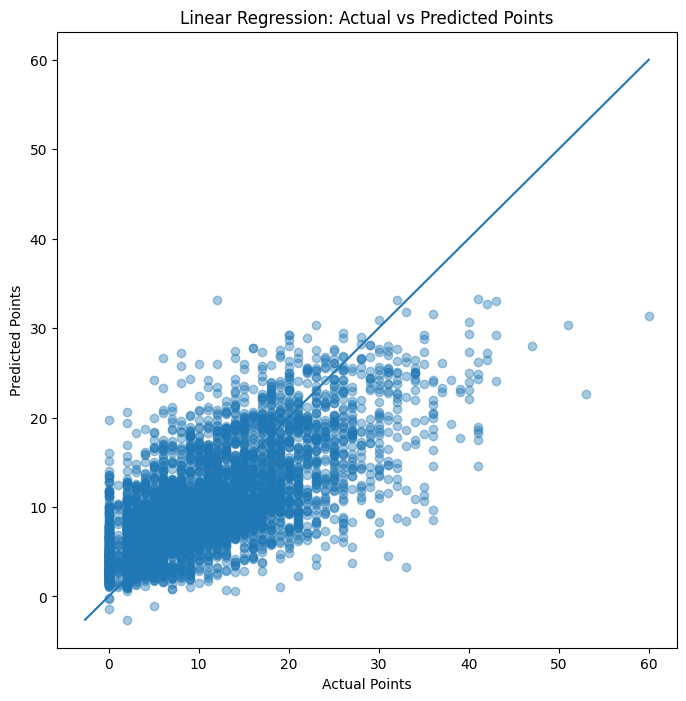

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.4
)

# Perfect prediction line
min_val = min(y_test.min(), linear_predictions.min())
max_val = max(y_test.max(), linear_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Linear Regression: Actual vs Predicted Points")

plt.show()

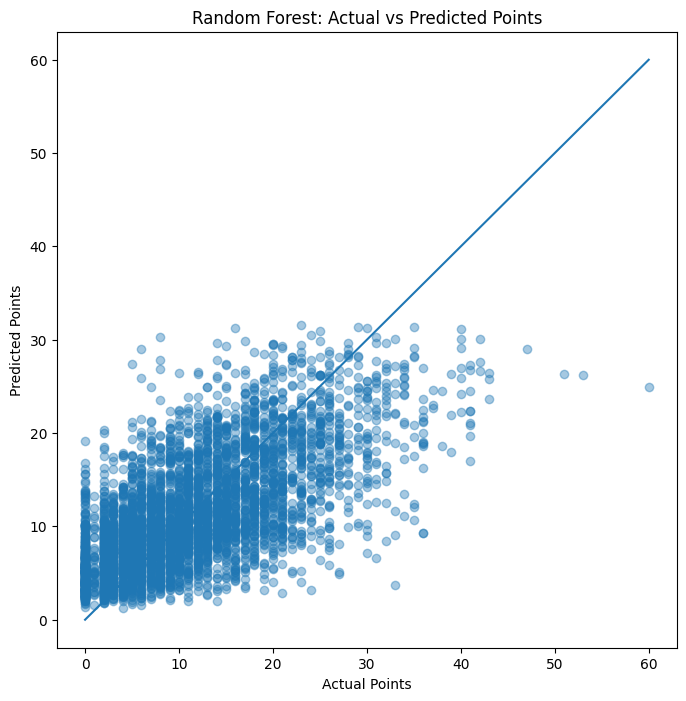

In [80]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.4
)

min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.xlabel("Actual Points")
plt.ylabel("Predicted Points")
plt.title("Random Forest: Actual vs Predicted Points")

plt.show()

In [ ]:
joblib.dump(features, "../models/feature_columns.pkl")

In [ ]:
import joblib

joblib.dump(linear_model, "../models/points_model.pkl")